# 4. Exploratory Data Analysis: Bay Area Solar InstallationsAnalysis of solar installations in the Bay Area / Peninsula region.**Owner:** _assign team member_**Status:** In Progress

## SetupRun `03_data_loading.ipynb` first to have `df` available, or load the data here.

In [ ]:
import osimport numpy as npimport pandas as pdimport matplotlib.pyplot as plt# Load data if not already in memory# Uncomment and adjust path as needed:# df = pd.read_csv('TTS_LBNL_public_file_29-Sep-2025_all.csv', encoding='latin1', low_memory=False)

## State Distribution

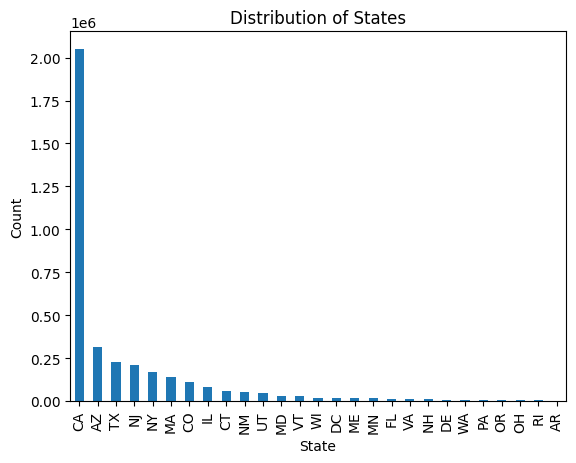

In [ ]:
import matplotlib.pyplot as plt

# Plot the distribution of states

df['state'].value_counts().plot(kind='bar')

plt.xlabel('State')
plt.ylabel('Count')
plt.title('Distribution of States')
plt.show()

## California ZIP Code Analysis

In [ ]:
!pip install pgeocode

In [ ]:
import pandas as pd
import pgeocode
import plotly.express as px

ca_zip_counts = (
    df.loc[df['state'] == 'CA', ['zip_code']]
      .dropna()
      .assign(zip_code=lambda x: x['zip_code'].astype(str).str.zfill(5))
      .groupby('zip_code')
      .size()
      .reset_index(name='count')
)

nomi = pgeocode.Nominatim('us')
coords = nomi.query_postal_code(ca_zip_counts['zip_code'].tolist())

coords = coords[['postal_code', 'latitude', 'longitude']].rename(
    columns={'postal_code': 'zip_code'}
)

plot_df = ca_zip_counts.merge(coords, on='zip_code', how='left')

fig = px.scatter_geo(
    plot_df.dropna(subset=['latitude', 'longitude']),
    lat='latitude',
    lon='longitude',
    size='count',
    hover_name='zip_code',
    scope='usa',
    title='California ZIP Code Distribution'
)
fig.show()

In [ ]:
ca_zips = df.loc[df['state'] == 'CA', 'zip_code'].unique()

## Bay Area / Peninsula Filtering

In [ ]:
import numpy as np

bay_area_zip_dict = {

    # -------------------------
    # SAN FRANCISCO
    # -------------------------
    "San Francisco": [
        "94102","94103","94104","94105","94107","94108","94109","94110",
        "94111","94112","94114","94115","94116","94117","94118","94121",
        "94122","94123","94124","94127","94129","94130","94131","94132",
        "94133","94134","94158"
    ],

    # -------------------------
    # SAN MATEO COUNTY (PENINSULA)
    # -------------------------
    "San Mateo County": [
        "94002","94005","94010","94011","94014","94015","94017","94018",
        "94019","94020","94021","94025","94026","94027","94028","94030",
        "94037","94038","94039","94044","94045","94046","94060","94061",
        "94062","94063","94064","94065","94066","94070","94071","94074",
        "94080","94083","94096","94098","94401","94402","94403","94404",
        "94497"
    ],

    # -------------------------
    # SANTA CLARA COUNTY (SAN JOSE METRO)
    # -------------------------
    "Santa Clara County": [
        "94022","94023","94024","94035","94040","94041","94042","94043",
        "94085","94086","94087","94088","94089",
        "94301","94302","94303","94304","94305","94306","94309",
        "95002","95008","95009","95011","95013","95014","95015","95020",
        "95021","95024","95026","95030","95031","95032","95033","95035",
        "95036","95037","95038","95042","95044","95046","95050","95051",
        "95052","95053","95054","95055","95056","95070","95071","95101",
        "95103","95106","95108","95109","95110","95111","95112","95113",
        "95115","95116","95117","95118","95119","95120","95121","95122",
        "95123","95124","95125","95126","95127","95128","95129","95130",
        "95131","95132","95133","95134","95135","95136","95138","95139",
        "95140","95141","95148","95150","95151","95152","95153","95154",
        "95155","95156","95157","95158","95159","95160","95161","95164",
        "95170","95172","95173","95190","95191","95192","95193","95194",
        "95196"
    ]
}

all_bay_area_zips = set(
    z for group in bay_area_zip_dict.values() for z in group
)

ca_zips["zip_clean"] = ca_zips["zip_code"].astype(str).str.extract(r"(\d{5})")[0]

bay_area_df = df[df["zip_clean"].isin(all_bay_area_zips)]

zip_to_region = {
    z: region
    for region, zips in bay_area_zip_dict.items()
    for z in zips
}

df["region"] = df["zip_clean"].map(zip_to_region)

df["region"].value_counts()

bay_area_df["zip_clean"].value_counts().head(20)

print(bay_area_df.shape)
print(bay_area_df["region"].value_counts())

bay_area_df.groupby("region").agg({
    "price_per_watt": "median",
    "PV_system_size_DC": "median",
    "battery_rated_capacity_kWh": "mean"
})

(134328, 25)


KeyError: 'region'

In [ ]:
import numpy as np
bay_area_prefixes = (
    "940",  # San Mateo County (Peninsula)
    "941",  # San Francisco (optional but usually included)
    "943",  # Palo Alto
    "944",  # San Mateo
    "950",  # Santa Clara County (Cupertino, Saratoga, Los Gatos, etc.)
    "951"   # San Jose
)

df["zip_clean"] = (
    df["zip_code"]
    .astype(str)
    .str.extract(r"(\d{5})")[0]  # keep only 5-digit ZIP
)

# peninsula_zips = df[
#     df["zip_clean"].str.startswith(tuple(peninsula_prefixes), na=False)
# ]["zip_clean"].unique()

# print(len(peninsula_zips))
# print(peninsula_zips[:20])

peninsula_df = df[
    df["zip_clean"].str.startswith(tuple(bay_area_prefixes), na=False)
]

print(len(peninsula_df))
peninsula_df.shape

155472


(155472, 25)

In [ ]:
peninsula_df = peninsula_df.replace(-1, np.nan)

## Peninsula Data Profiling

In [ ]:
peninsula_df.columns

Index(['installation_date', 'PV_system_size_DC', 'total_installed_price',
       'rebate_or_grant', 'customer_segment', 'tracking', 'ground_mounted',
       'zip_code', 'state', 'utility_service_territory', 'third_party_owned',
       'installer_name', 'azimuth_1', 'tilt_1', 'module_manufacturer_1',
       'module_model_1', 'module_quantity_1', 'technology_module_1',
       'efficiency_module_1', 'inverter_manufacturer_1', 'inverter_model_1',
       'output_capacity_inverter_1', 'inverter_loading_ratio',
       'battery_rated_capacity_kWh', 'zip_clean'],
      dtype='object')

In [ ]:
for col in peninsula_df.columns:
    print(col, len(peninsula_df[col].unique()))

installation_date 6064
PV_system_size_DC 16298
total_installed_price 60947
rebate_or_grant 9728
customer_segment 9
tracking 3
ground_mounted 3
zip_code 203
state 5
utility_service_territory 14
third_party_owned 3
installer_name 1939
azimuth_1 362
tilt_1 80
module_manufacturer_1 214
module_model_1 3156
module_quantity_1 829
technology_module_1 7
efficiency_module_1 1603
inverter_manufacturer_1 97
inverter_model_1 1263
output_capacity_inverter_1 332
inverter_loading_ratio 29827
battery_rated_capacity_kWh 294
zip_clean 183
price_per_watt 88582
year 27


In [ ]:
peninsula_df.state.unique()

array(['CA', 'AZ', 'NJ', 'UT', 'MN'], dtype=object)

## Feature Engineering

In [ ]:
peninsula_df["price_per_watt"] = (
    peninsula_df["total_installed_price"] /
    (peninsula_df["PV_system_size_DC"] * 1000)
)

peninsula_df["installation_date"] = pd.to_datetime(
    peninsula_df["installation_date"], errors="coerce"
)

peninsula_df["year"] = peninsula_df["installation_date"].dt.year

## Descriptive Statistics & Trends

In [ ]:
peninsula_df['PV_system_size_DC'].describe()

In [ ]:
peninsula_df.groupby("year")["PV_system_size_DC"].median().plot()

In [ ]:
# peninsula_df['price_per_watt'].clip(0,10).hist()
peninsula_df.groupby("year")["price_per_watt"].median().plot()

## Segment & Installer Analysis

In [ ]:
peninsula_df["customer_segment"].value_counts().plot(kind="bar")

In [ ]:
peninsula_df["third_party_owned"].value_counts(normalize=True)

In [ ]:
top_installers = peninsula_df["installer_name"].value_counts().head(10)

top_installers.plot(kind="bar")

## Geographic Analysis

In [ ]:
zip_summary = peninsula_df.groupby("zip_clean").agg({
    "price_per_watt": "median",
    "PV_system_size_DC": "median"
}).sort_values("price_per_watt", ascending=False)

zip_summary.head(10)

In [ ]:
peninsula_df.plot.scatter(
    x="PV_system_size_DC",
    y="price_per_watt",
    alpha=0.1
)

## Battery & Cost Distributions

In [ ]:
peninsula_df["has_battery"] = peninsula_df["battery_rated_capacity_kWh"].notna()

peninsula_df.groupby("year")["has_battery"].mean().plot()

In [ ]:
peninsula_df.boxplot(
    column="price_per_watt",
    by="customer_segment",
    rot=45
)

In [ ]:
peninsula_df.boxplot(
    column="price_per_watt",
    by="year",
    rot=90
)

In [ ]:
peninsula_df["price_per_watt"].clip(0, 10).plot(kind="kde")

## Year-over-Year Summary

In [ ]:
summary = peninsula_df.groupby("year").agg({
    "price_per_watt": ["median", "mean"],
    "PV_system_size_DC": ["median"],
    "battery_rated_capacity_kWh": ["mean"]
})
summary

## Regional Comparison

In [ ]:
# REGION LABELS
def zip_to_region(zip_code):
    if pd.isna(zip_code):
        return "Unknown"

    z = str(zip_code)[:3]

    if z in ["940", "943", "944"]:
        return "Peninsula"
    elif z in ["950", "951"]:
        return "San Jose Metro"
    elif z in ["941"]:
        return "San Francisco"
    else:
        return "Other"

df["region"] = df["zip_clean"].apply(zip_to_region)

# AGGREGATE & PLOT
region_summary = df.groupby("region").agg({
    "price_per_watt": "median",
    "PV_system_size_DC": "median",
    "battery_rated_capacity_kWh": "mean"
}).reset_index()

region_summary.plot(
    x="region",
    y="price_per_watt",
    kind="bar"
)

In [ ]:
peninsula_df["region"] = np.where(
    df["zip_clean"].str.startswith(bay_area_prefixes, na=False),
    "Bay Area",
    "Other CA"
)

comparison = df.groupby("region").agg({
    "price_per_watt": "median",
    "PV_system_size_DC": "median"
})

print(comparison)